# Clustering new data points

PLSCAN provides HDBSCAN*-style approximate prediction for unseen feature vectors via `fast_plscan.prediction.approximate_predict`.

Given a fitted `PLSCAN` model and new points, approximate prediction:

1. Uses the neighbor tree built during `fit` (no tree rebuild).
2. Connects each new point through mutual reachability distance.
3. Returns an approximate cluster label and probability in `[0, 1]`.

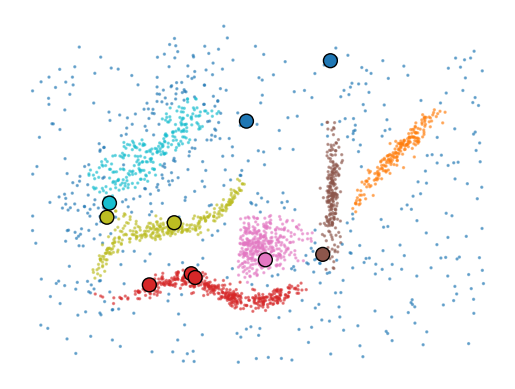

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from fast_plscan import PLSCAN
from fast_plscan.prediction import approximate_predict

X = np.load("data/clusterable/sources/clusterable_data.npy").astype(np.float32)
clusterer = PLSCAN(min_samples=5).fit(X)

rng = np.random.Generator(np.random.PCG64(40))
X_new = X[rng.choice(X.shape[0], 10, replace=False)] + 0.015
labels, probabilities = approximate_predict(clusterer, X_new)

plt.scatter(*X.T, c=clusterer.labels_, cmap="tab10", s=2, alpha=0.5)
plt.scatter(*X_new.T, c=labels, cmap="tab10", s=100, edgecolor="k")
plt.axis("off")
plt.show()